# Comparing pQCD posterior to Komoltsev & Kurkela (2022)

## Imports

In [1]:
import h5py 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter")
import utils
from utils import meraki

/home/sunny.ng/semiparameos/executables/TOVSolver.py:17: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Constants & conversion factors

In [2]:
### Nucleon mass in grams
mass_of_nucleon = 1/(6.02 * 10**23)
### Nucleon mass in MeV/c2
nucleon_mass_in_MeV = 939
### Conversion factors for Mev,fm to CGS units
gcm3_to_dynecm2=8.9875e20 
MeV_to_gcm3 = 1.7827e12 
MeVfm3_to_dynecm2 = 1.6022e33    # 1 MeV * fm^-3 in dyne * cm^-2
gcm3_to_fm4 = 3.5178e14

fm_in_cgs = 1e-13
rho_nuc_in_cgs = .16 * mass_of_nucleon / (fm_in_cgs)**3

## Plotting pQCD values of $n$ and $p$ over posterior

In [3]:
### Laying out plot densities and percentiles
plot_densities = np.geomspace(np.power(10.0, 13.0), 40.0 * rho_nuc_in_cgs, 500)
percentiles = [5, 95]

In [4]:
### Getting prior quantiles
prior_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/prior_pinched.h5"
prior_samples = meraki.EOS.load_samples(prior_h5_path, load_micro = True)
prior_pe_quantiles = prior_samples.get_pe_quantiles(plot_densities, percentiles)
prior_cs_quantiles = prior_samples.get_cs_quantiles(plot_densities, percentiles)

In [5]:
### Getting conformal quantiles
conformal_h5_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit/conformal.h5"
conformal_samples = meraki.EOS.load_samples(conformal_h5_path, load_micro = True)
conformal_pe_quantiles = conformal_samples.get_pe_quantiles(plot_densities, percentiles)
conformal_cs_quantiles = conformal_samples.get_cs_quantiles(plot_densities, percentiles)

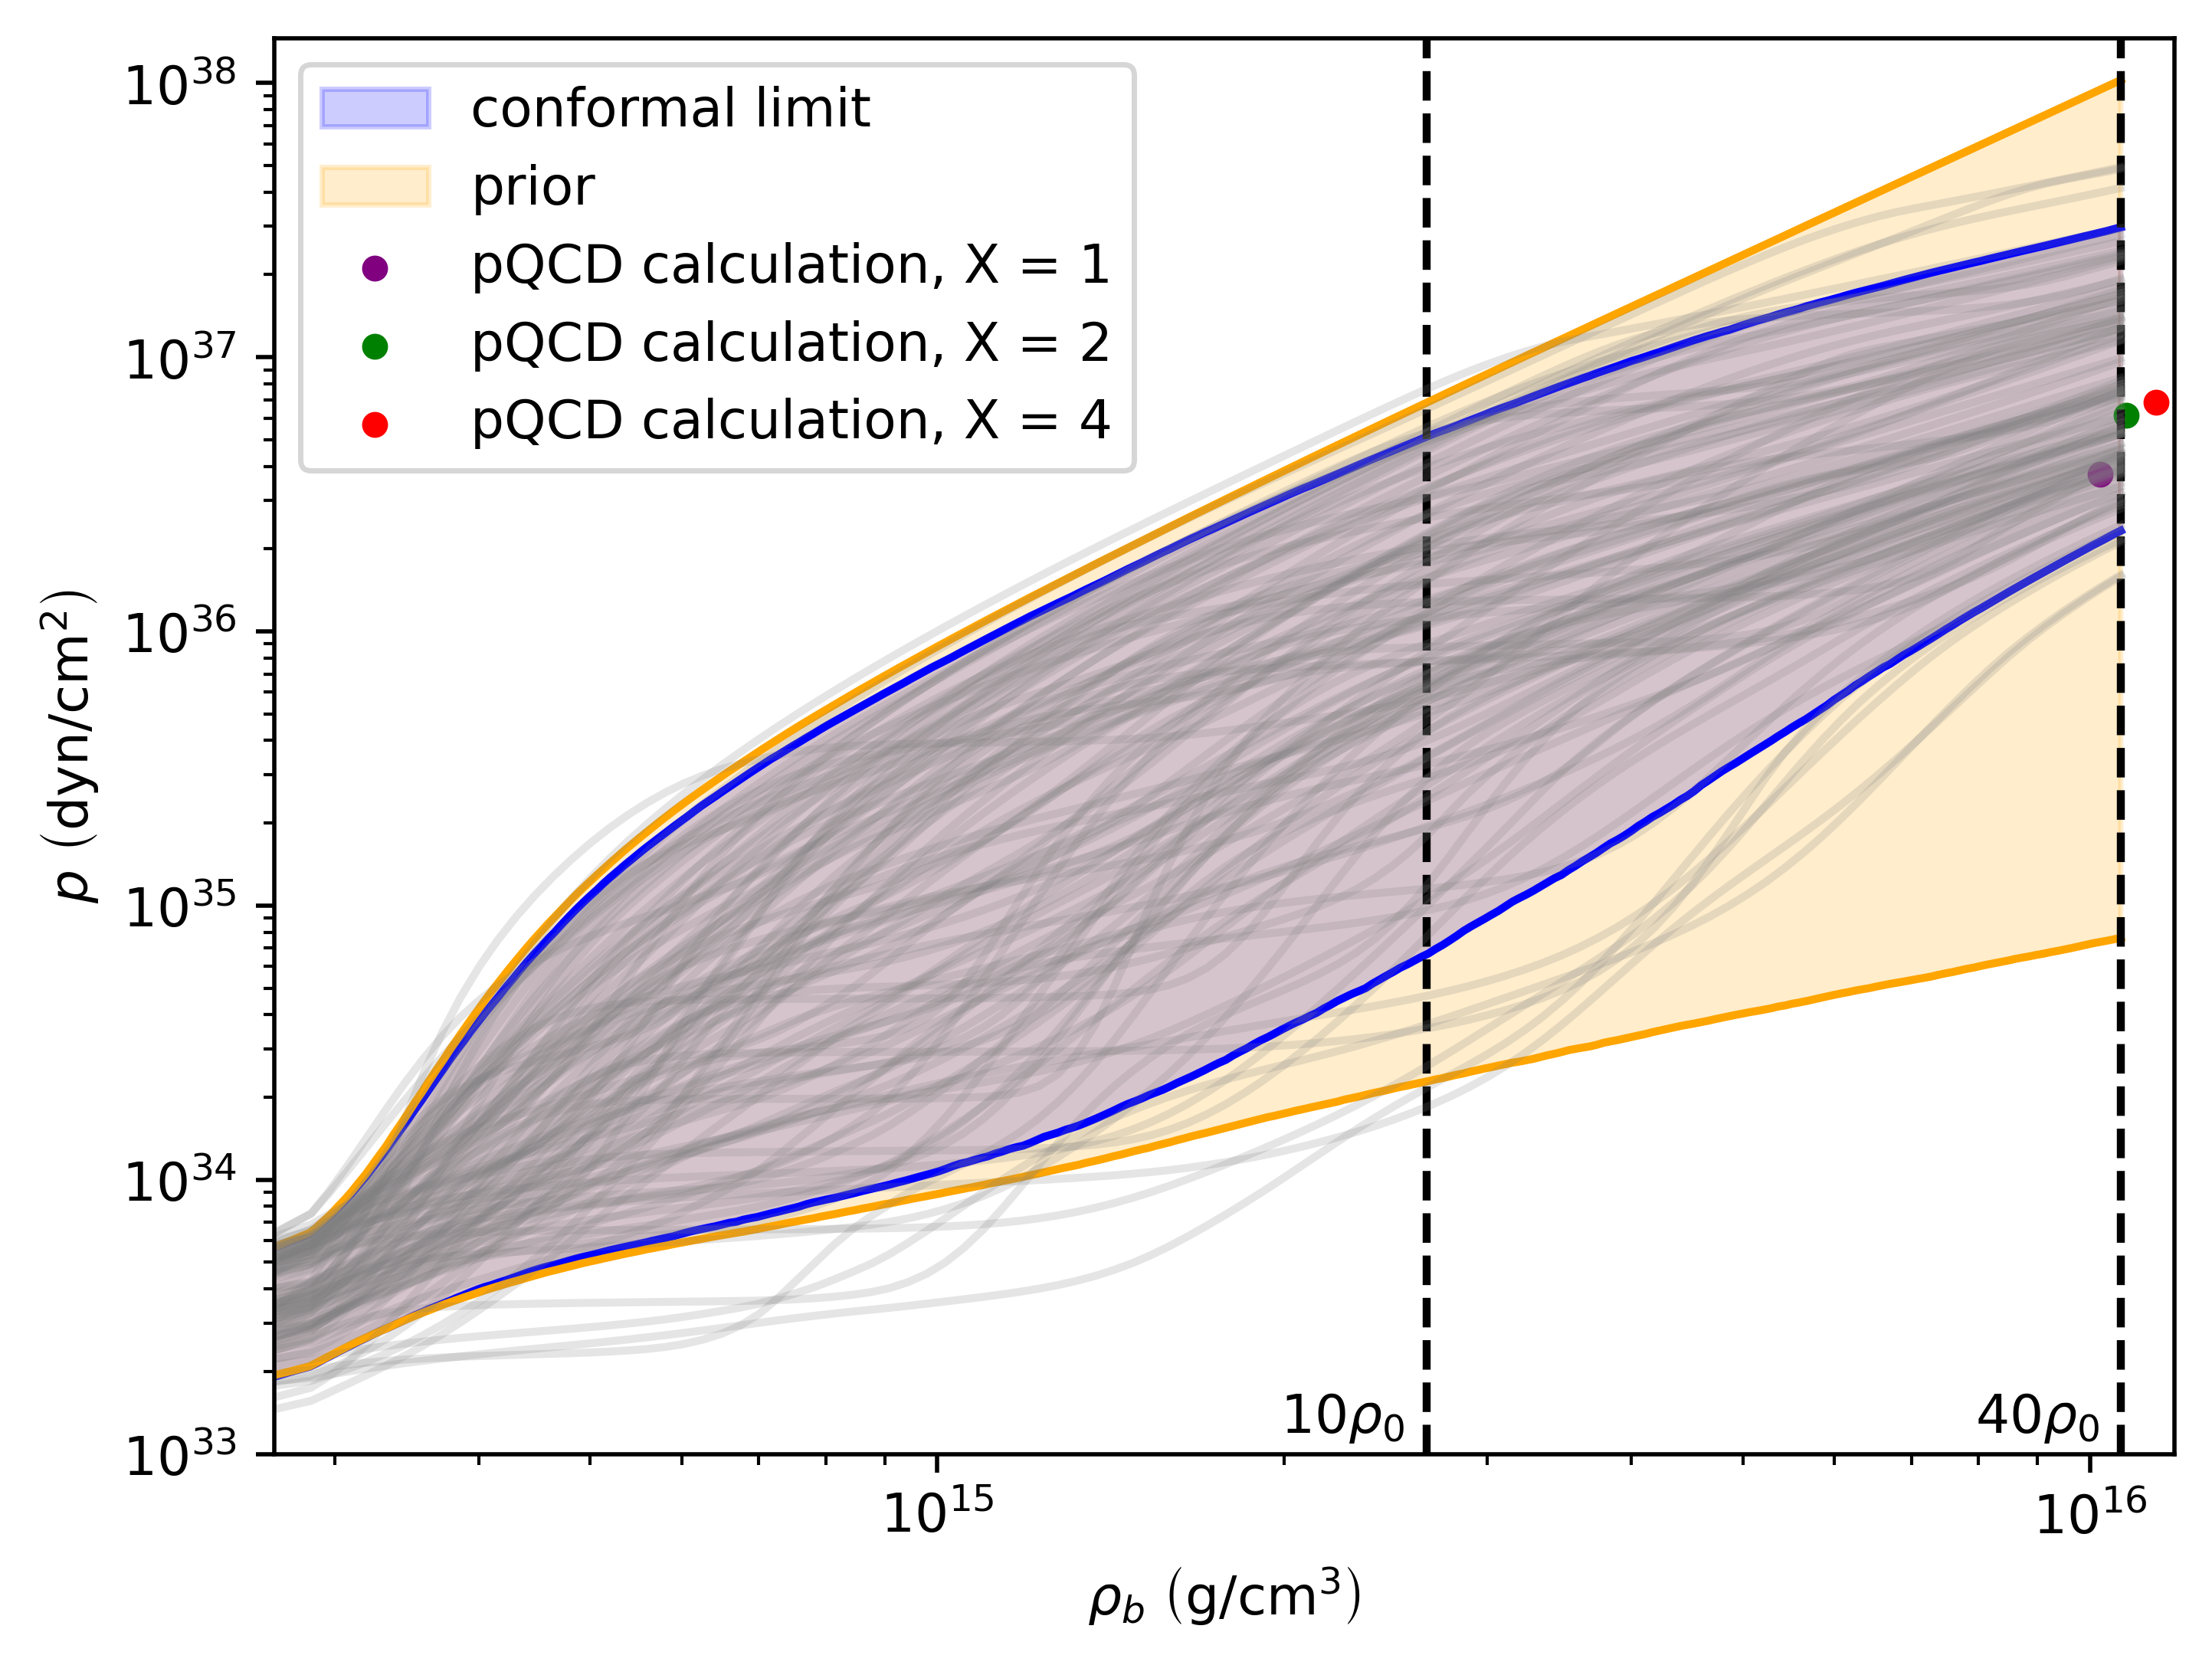

In [30]:
# Pressure contour
plt.loglog();
plt.xlabel(r"$\rho_b$ $\left(\mathrm{g}/\mathrm{cm}^3\right)$");
plt.ylabel(r"$p$ $\left(\mathrm{dyn}/\mathrm{cm}^2\right)$");
plt.xlim(1.0 * rho_nuc_in_cgs, 44.5 * rho_nuc_in_cgs);
y_min = 10.0 ** 33
plt.ylim(y_min, 10.1 ** 38);

plt.fill_between(plot_densities,
                 conformal_pe_quantiles[:, 0],
                 conformal_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "blue",
                 label = "conformal limit"
                )

plt.fill_between(plot_densities,
                 prior_pe_quantiles[:, 0],
                 prior_pe_quantiles[:, 1],
                 alpha = 0.2,
                 color = "orange",
                 label = "prior"
                )

plt.plot(plot_densities,
         conformal_pe_quantiles,
         color = "blue"
        );

plt.plot(plot_densities,
         prior_pe_quantiles,
         color = "orange"
        );

#######################################################

# Plotting pQCD calculations of n and p from Komoltsev & Kurkela
n_pQCD_1 = 6.14    # Renormalization scale parameter = 1, units are fm^-3
p_pQCD_1 = 2334.0  # Renormalization scale parameter = 1, units are MeV * fm^-3

n_pQCD_2 = 6.47    # Renormalization scale parameter = 2, units are fm^-3
p_pQCD_2 = 3823.0  # Renormalization scale parameter = 2, units are MeV * fm^-3

n_pQCD_4 = 6.87    # Renormalization scale parameter = 4, units are fm^-3
p_pQCD_4 = 4284.0  # Renormalization scale parameter = 4, units are MeV * fm^-3

# Converting units to cgs
rho_pQCD_1 = n_pQCD_1 * mass_of_nucleon / (fm_in_cgs) ** 3
p_pQCD_1 *= MeVfm3_to_dynecm2

rho_pQCD_2 = n_pQCD_2 * mass_of_nucleon / (fm_in_cgs) ** 3
p_pQCD_2 *= MeVfm3_to_dynecm2

rho_pQCD_4 = n_pQCD_4 * mass_of_nucleon / (fm_in_cgs) ** 3
p_pQCD_4 *= MeVfm3_to_dynecm2

# Plotting
plt.scatter(rho_pQCD_1,
            p_pQCD_1,
            color = "purple",
            s = 15,
            label = "pQCD calculation, X = 1"
           )

plt.scatter(rho_pQCD_2,
            p_pQCD_2,
            color = "green",
            s = 15,
            label = "pQCD calculation, X = 2"
           )

plt.scatter(rho_pQCD_4,
            p_pQCD_4,
            color = "red",
            s = 15,
            label = "pQCD calculation, X = 4"
           )

###############################################################################

# Plotting rho_nuc markers
markers = [10.0, 40.0]

for i in range(np.size(markers)):
    plt.axvline(x = markers[i] * rho_nuc_in_cgs,
                linestyle = "--",
                color = "black"
               );

    plt.text(x = (markers[i] - 1.6 * np.exp(0.046 * markers[i])) * rho_nuc_in_cgs,
             y = y_min * 1.2,
             s = f"${int(markers[i])}$"r"$\rho_0$"
            )

# Plotting example draws of conformal EoS
project_path = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/conformal_limit"
conformal_h5_path = f"{project_path}/conformal.h5"
eos_indices = pd.read_csv(f"{project_path}/astro_likelihoods/conformal_weights_unpinched.csv")["eos_index"].to_numpy()

with h5py.File(conformal_h5_path) as h5_file:
    eos_data = h5_file["eos"]
    for i in range(100):
        sample = np.random.randint(0, len(eos_data))
        sample_key = f"eos_{eos_indices[sample]:06d}"
        
        plt.plot(eos_data[sample_key]["baryon_density"],
                 eos_data[sample_key]["pressurec2"] * gcm3_to_dynecm2,
                 color = "grey",
                 alpha = 0.2
                );

    h5_file.close()

plt.gcf().set_dpi(500)
plt.legend();

# Saving plot        
plot_folder = "/home/ryan.krismer/CSUF_EoS_project/ns_dense_matter/plots"
plt.savefig(f"{plot_folder}/comparison_to_pQCD_calculations.jpg", bbox_inches = "tight");
plt.savefig(f"{plot_folder}/comparison_to_pQCD_calculations.pdf", bbox_inches = "tight");